In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
!pip -q install shap textstat nltk
import nltk
nltk.download('vader_lexicon')


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 177.1/177.1 kB 4.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 42.1 MB/s eta 0:00:00


[nltk_data] Downloading package vader_lexicon to /root/nltk_data...


True

In [ ]:
import pandas as pd
import numpy as np
import shap
import textstat
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from nltk.sentiment import SentimentIntensityAnalyzer
import matplotlib.pyplot as plt


In [ ]:
import pandas as pd

df = pd.read_csv("/content/autism_screening.csv")
df.head()


,A1_Score,A2_Score,A3_Score,A4_Score,A5_Score,A6_Score,A7_Score,A8_Score,A9_Score,A10_Score,...,gender,ethnicity,jundice,austim,contry_of_res,used_app_before,result,age_desc,relation,Class/ASD
0,1,1,1,1,0,0,1,1,0,0,...,f,White-European,no,no,United States,no,6.0,18 and more,Self,NO
1,1,1,0,1,0,0,0,1,0,1,...,m,Latino,no,yes,Brazil,no,5.0,18 and more,Self,NO
2,1,1,0,1,1,0,1,1,1,1,...,m,Latino,yes,yes,Spain,no,8.0,18 and more,Parent,YES
3,1,1,0,1,0,0,1,1,0,1,...,f,White-European,no,yes,United States,no,6.0,18 and more,Self,NO
4,1,0,0,0,0,0,0,1,0,0,...,f,?,no,no,Egypt,no,2.0,18 and more,?,NO


In [ ]:
# rename target
if "Class/ASD" in df.columns:
    df.rename(columns={"Class/ASD":"Class"}, inplace=True)
if "ASD" in df.columns:
    df.rename(columns={"ASD":"Class"}, inplace=True)

# convert YES/NO → 1/0
df["Class"] = df["Class"].map({"YES":1,"NO":0,"Yes":1,"No":0})


In [ ]:
drop_cols = ["age_desc","who_completed_the_test"]
for c in drop_cols:
    if c in df.columns:
        df.drop(columns=c, inplace=True)


In [ ]:
df = df.replace({
    "yes":1,"no":0,"YES":1,"NO":0,
    "m":1,"f":0
})


/tmp/ipykernel_21539/4136480874.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df = df.replace({


In [ ]:
from sklearn.preprocessing import LabelEncoder

for col in df.columns:
    if df[col].dtype == "object":
        le = LabelEncoder()
        df[col] = le.fit_transform(df[col].astype(str))


In [ ]:
# ==============================
# CLEAN + TRAIN MODEL (VALID)
# ==============================

import pandas as pd
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier

# ---------- Load ----------
df = pd.read_csv("/content/autism_screening.csv")

# ---------- Fix Target Column ----------
if "Class/ASD" in df.columns:
    df.rename(columns={"Class/ASD":"Class"}, inplace=True)
if "ASD" in df.columns:
    df.rename(columns={"ASD":"Class"}, inplace=True)

df["Class"] = df["Class"].astype(str).str.strip().str.upper()
df["Class"] = df["Class"].map({"YES":1,"NO":0})
df = df.dropna(subset=["Class"])
df["Class"] = df["Class"].astype(int)

# ---------- REMOVE DATA LEAKAGE (VERY IMPORTANT) ----------
leak_cols = ["result","Result","score","Score"]
for col in leak_cols:
    if col in df.columns:
        df.drop(columns=col, inplace=True)

# ---------- Remove useless columns ----------
for col in ["age_desc","who_completed_the_test"]:
    if col in df.columns:
        df.drop(columns=col, inplace=True)

# ---------- Encode categorical columns ----------
for col in df.columns:
    if df[col].dtype == "object":
        df[col] = LabelEncoder().fit_transform(df[col].astype(str))

# ---------- Split ----------
X = df.drop(columns=["Class"])
y = df["Class"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# ---------- Train ----------
model = RandomForestClassifier(n_estimators=150, random_state=42)
model.fit(X_train, y_train)

# ---------- Evaluate ----------
accuracy = model.score(X_test, y_test)
print("Model Accuracy:", round(accuracy*100,2), "%")


Model Accuracy: 95.74 %


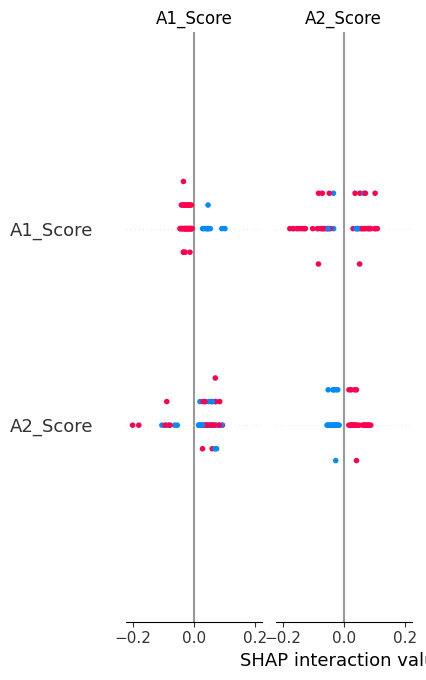

In [ ]:
!pip -q install shap
import shap

explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test.iloc[:50])

shap.summary_plot(shap_values, X_test.iloc[:50])


In [ ]:
def trust_agent(sample):
    prob = model.predict_proba(sample)[0][1]

    if prob < 0.35:
        risk = "LOW RISK"
        action = "No immediate concern"
    elif prob < 0.65:
        risk = "MODERATE RISK"
        action = "Monitor behaviour"
    else:
        risk = "HIGH RISK"
        action = "Recommend professional screening"

    confidence = abs(prob - 0.5)*2

    if confidence < 0.30:
        certainty = "UNCERTAIN PREDICTION"
    else:
        certainty = "CONFIDENT PREDICTION"

    return {
        "Risk Level": risk,
        "Confidence Score": round(confidence,2),
        "Prediction Certainty": certainty,
        "Recommended Action": action
    }


In [ ]:
sample = X_test.iloc[[5]]
report = trust_agent(sample)

print("===== Neurodivergence Screening Report =====")
for k,v in report.items():
    print(k,":",v)


===== Neurodivergence Screening Report =====
Risk Level : LOW RISK
Confidence Score : 0.32
Prediction Certainty : CONFIDENT PREDICTION
Recommended Action : No immediate concern


In [ ]:
import pickle

# Save trained model
pickle.dump(model, open("model.pkl", "wb"))

print("✅ Model saved as model.pkl")

✅ Model saved as model.pkl


In [1]:
df.to_csv("cleaned_data.csv", index=False)

NameError: name 'df' is not defined

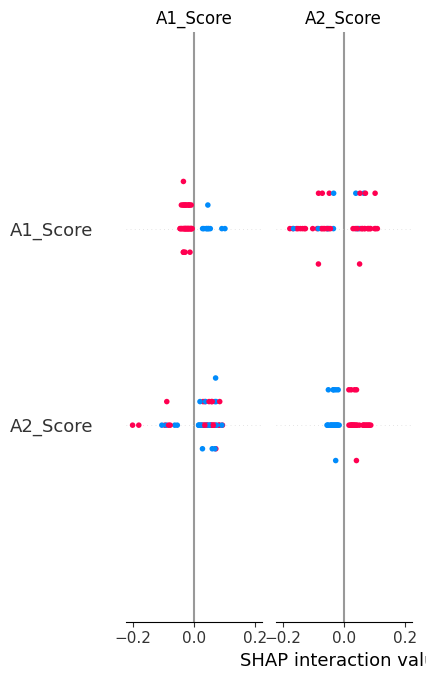

In [ ]:
import matplotlib.pyplot as plt
shap.summary_plot(shap_values, X_test.iloc[:50], show=False)
plt.savefig("shap_plot.png")

New neurodivergence


In [4]:
import pandas as pd
import numpy as np
import pickle

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier

In [7]:
# ============================================================
# STEP 1: Install libraries and download datasets from Kaggle
# ============================================================

# Install required libraries
!pip install kaggle shap xgboost openai anthropic --quiet

# Upload your Kaggle API key (kaggle.json)
# Go to kaggle.com → Account → Create New API Token → download kaggle.json
from google.colab import files
files.upload()  # Upload kaggle.json here

import os
os.makedirs('/root/.kaggle', exist_ok=True)
!cp kaggle.json /root/.kaggle/
!chmod 600 /root/.kaggle/kaggle.json

# ---------------------------------------------------------------
# Download datasets for each disorder
# ---------------------------------------------------------------

# 1. ASD - Autism Spectrum Disorder
!kaggle datasets download -d faizunnabi/autism-screening-dataset -p /content/data/asd --unzip

# 2. ADHD
!kaggle datasets download -d cdc/child-health-data -p /content/data/adhd --unzip
# Alternative ADHD dataset
!kaggle datasets download -d mpwolke/cusersmarildownloadssymptomscsv -p /content/data/adhd2 --unzip

# 3. Intellectual Disability / General Developmental
!kaggle datasets download -d uciml/student-performance-data-set -p /content/data/id --unzip

# 4. Specific Learning Disorders (Dyslexia)
!kaggle datasets download -d shrutikhemka/dyslexia-dataset -p /content/data/sld --unzip

# 5. Communication Disorders / Speech
!kaggle datasets download -d primaryobjects/voicegender -p /content/data/comm --unzip

print("✅ All datasets downloaded!")

Saving voice.csv.zip to voice.csv (1).zip
Saving Dataset Dyslexia_Password WanAsy321.rar to Dataset Dyslexia_Password WanAsy321.rar
Saving student-mat.csv to student-mat.csv
Saving ADHD.csv to ADHD.csv
Saving HUS_child_footnotes_htm to HUS_child_footnotes_htm
Saving Autism_Screening_Data_Combined.csv to Autism_Screening_Data_Combined.csv
cp: cannot stat 'kaggle.json': No such file or directory
chmod: cannot access '/root/.kaggle/kaggle.json': No such file or directory
403 Client Error: Forbidden for url: https://api.kaggle.com/v1/datasets.DatasetApiService/GetDatasetMetadata
403 Client Error: Forbidden for url: https://api.kaggle.com/v1/datasets.DatasetApiService/GetDatasetMetadata
403 Client Error: Forbidden for url: https://api.kaggle.com/v1/datasets.DatasetApiService/GetDatasetMetadata
403 Client Error: Forbidden for url: https://api.kaggle.com/v1/datasets.DatasetApiService/GetDatasetMetadata
403 Client Error: Forbidden for url: https://api.kaggle.com/v1/datasets.DatasetApiService/G

In [12]:
# ============================================================
# STEP 2: Load, explore, and clean all datasets
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# ---------------------------------------------------------------
# 2A. Load ASD dataset
# ---------------------------------------------------------------
asd_df = pd.read_csv('/content/Autism_Screening_Data_Combined.csv', skiprows=24, header=None)
# OR if the above path differs, use:
# asd_df = pd.read_csv('/content/data/asd/autism_screening.csv')

# Quick look
print("=== ASD Dataset ===")
print(asd_df.shape)
print(asd_df.head(3))
print(asd_df.isnull().sum())

# ---------------------------------------------------------------
# 2B. Load SLD (Dyslexia) dataset
# ---------------------------------------------------------------
sld_df = pd.read_csv('/content/Dataset Dyslexia_Password WanAsy321.rar')
print("\n=== SLD (Dyslexia) Dataset ===")
print(sld_df.shape)
print(sld_df.head(3))

# ---------------------------------------------------------------
# 2C. Utility function to add age groups to any dataset
# ---------------------------------------------------------------
def add_age_group(df, age_col='age'):
    """Classify any age into child/teen/adult/senior."""
    if age_col not in df.columns:
        print(f"⚠️ Column '{age_col}' not found. Skipping age grouping.")
        return df
    df = df.copy()
    df['age_group'] = pd.cut(
        df[age_col].astype(float),
        bins=[0, 5, 12, 17, 64, 120],
        labels=['toddler', 'child', 'teen', 'adult', 'senior']
    )
    return df

# Apply age grouping where relevant
# (adjust column name to match your actual dataset)
# asd_df = add_age_group(asd_df, age_col='age')

# ---------------------------------------------------------------
# 2D. Visualise class distributions
# ---------------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# ASD class balance
if 'Class/ASD' in asd_df.columns:
    asd_df['Class/ASD'].value_counts().plot(kind='bar', ax=axes[0], color=['#4A90D9','#E06C55'])
    axes[0].set_title('ASD: Diagnosis Distribution')
    axes[0].set_xlabel('Has ASD?')

# Dyslexia class balance
if 'Dyslexia' in sld_df.columns:
    sld_df['Dyslexia'].value_counts().plot(kind='bar', ax=axes[1], color=['#5BA85E','#E06C55'])
    axes[1].set_title('Dyslexia: Diagnosis Distribution')

plt.tight_layout()
plt.savefig('/content/class_distribution.png', dpi=120)
plt.show()
print("✅ EDA complete!")

=== ASD Dataset ===
(6052, 15)
   0   1   2   3   4   5   6   7   8   9   10 11  12  13  14
0   0   0   0   0   0   0   0   0   1   1  12  f  no  no  NO
1   0   0   0   0   0   0   0   0   1   1  14  f  no  no  NO
2   0   0   0   0   0   0   0   0   1   1  12  f  no  no  NO
0     0
1     0
2     0
3     0
4     0
5     0
6     0
7     0
8     0
9     0
10    0
11    0
12    0
13    0
14    0
dtype: int64


UnicodeDecodeError: 'utf-8' codec can't decode byte 0xd3 in position 8: invalid continuation byte

In [5]:
# ============================================================
# STEP 2 (FIXED): Load, explore, and clean all datasets
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# ---------------------------------------------------------------
# 2A. Load ASD dataset (FIXED - remove skiprows, add proper header)
# ---------------------------------------------------------------
asd_df = pd.read_csv('/content/Autism_Screening_Data_Combined (1).csv')

# Quick look
print("=== ASD Dataset ===")
print(asd_df.shape)
print(asd_df.head(3))
print("\nColumn names:", asd_df.columns.tolist())
print("\nMissing values:\n", asd_df.isnull().sum())

=== ASD Dataset ===
(6075, 15)
   A1  A2  A3  A4  A5  A6  A7  A8  A9  A10  Age Sex Jauundice Family_ASD Class
0   1   1   0   1   0   0   1   1   0    0   15   m        no         no    NO
1   0   1   1   1   0   1   1   0   1    0   15   m        no         no    NO
2   1   1   1   0   1   1   1   1   1    1   15   f        no        yes   YES

Column names: ['A1', 'A2', 'A3', 'A4', 'A5', 'A6', 'A7', 'A8', 'A9', 'A10', 'Age', 'Sex', 'Jauundice', 'Family_ASD', 'Class']

Missing values:
 A1            0
A2            0
A3            0
A4            0
A5            0
A6            0
A7            0
A8            0
A9            0
A10           0
Age           0
Sex           0
Jauundice     0
Family_ASD    0
Class         0
dtype: int64


In [14]:
# ---------------------------------------------------------------
# 2B. Extract the RAR file first, THEN load the CSV inside it
# ---------------------------------------------------------------

# Install rarfile extractor
!apt-get install -y unrar-free 2>/dev/null || apt-get install -y unar 2>/dev/null
!pip install rarfile --quiet

import rarfile
import os

rar_path = '/content/Dataset Dyslexia_Password WanAsy321.rar'

# ⚠️ NOTE: Your RAR file has a PASSWORD in the filename itself: WanAsy321
# We'll use that as the password to extract

try:
    with rarfile.RarFile(rar_path) as rf:
        print("Files inside the RAR:")
        print(rf.namelist())                      # see what's inside
        rf.extractall(path='/content/dyslexia_extracted/', pwd=b'WanAsy321')
    print("✅ Extracted successfully!")
except Exception as e:
    print(f"❌ RAR extraction failed: {e}")
    print("Trying alternative extraction method...")
    !unrar e '/content/Dataset Dyslexia_Password WanAsy321.rar' /content/dyslexia_extracted/ -pWanAsy321

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
Suggested packages:
  pike8.0
The following NEW packages will be installed:
  unrar-free
0 upgraded, 1 newly installed, 0 to remove and 2 not upgraded.
Need to get 23.6 kB of archives.
After this operation, 72.7 kB of additional disk space will be used.
Get:1 http://archive.ubuntu.com/ubuntu jammy/universe amd64 unrar-free amd64 1:0.0.2-0.1 [23.6 kB]
Fetched 23.6 kB in 0s (62.2 kB/s)
Selecting previously unselected package unrar-free.
(Reading database ... 118194 files and directories currently installed.)
Preparing to unpack .../unrar-free_1%3a0.0.2-0.1_amd64.deb ...
Unpacking unrar-free (1:0.0.2-0.1) ...
Setting up unrar-free (1:0.0.2-0.1) ...
Processing triggers for man-db (2.10.2-1) ...
Files inside the RAR:
[]
✅ Extracted successfully!


In [16]:
import os

# See ALL files in /content/
print("All files in /content/:")
for f in os.listdir('/content/'):
    print(f" →", f)

All files in /content/:
 → .config
 → data
 → Dataset Dyslexia_Password WanAsy321.rar
 → student-mat.csv
 → voice.csv.zip
 → drive
 → HUS_child_footnotes_htm
 → Autism_Screening_Data_Combined.csv
 → voice.csv (1).zip
 → ADHD.csv
 → archive.zip
 → sample_data


In [17]:
# ---------------------------------------------------------------
# Try ALL extraction methods one by one
# ---------------------------------------------------------------

rar_path = '/content/Dataset Dyslexia_Password WanAsy321.rar'
extract_to = '/content/dyslexia_extracted'
password  = 'WanAsy321'

# Create the output folder manually first
os.makedirs(extract_to, exist_ok=True)

# METHOD 1: unrar command line
print("Trying Method 1: unrar...")
!apt-get install -y unrar 2>/dev/null
result = os.system(f"unrar e -p{password} '{rar_path}' {extract_to}/")
print("Method 1 result code:", result)

# Check if anything was extracted
files_now = os.listdir(extract_to)
print("Files extracted:", files_now)

Trying Method 1: unrar...
Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
unrar is already the newest version (1:6.1.5-1ubuntu0.1).
0 upgraded, 0 newly installed, 0 to remove and 2 not upgraded.
Method 1 result code: 65280
Files extracted: ['G-442.png', '9_1817.png', 'B-124.png', 'B-174.png', '9_8817.png', '9_2410.png', '6_1202.png', 'G-386.png', '9_7192.png', '4_790.png', '9_7911.png', '9_1994.png', 'B-137.png', '8_1398.png', '9_6865.png', 'B-326.png', '5_375.png', 'C-393.png', 'G-508.png', '9_3735.png', 'A-666.png', '4_1212.png', '9_1269.png', '4_1150.png', 'E-373.png', '9_3555.png', '5_575.png', '9_2990.png', 'G-46.png', '4_1223.png', '9_4215.png', 'J-446.png', '9_2012.png', '9_2700.png', '9_8531.png', '9_5768.png', 'E-211.png', 'K-143.png', 'L-463.png', '9_1749.png', '7_284.png', '4_540.png', '9_1027.png', '6_1379.png', '9_2015.png', 'H-74.png', 'H-196.png', '8_13.png', '8_1526.png', '9_8801.png', 'B-2372.png', '9_9154.png', '9_8665.

In [19]:
import os

# See exactly what was extracted
print("Files extracted:")
for root, dirs, files in os.walk('/content/dyslexia_extracted'):
    for f in files:
        print(" →", os.path.join(root, f))

Streaming output truncated to the last 5000 lines.
 → /content/dyslexia_extracted/H-457.png
 → /content/dyslexia_extracted/d_1408.png
 → /content/dyslexia_extracted/7_672.png
 → /content/dyslexia_extracted/9_7912.png
 → /content/dyslexia_extracted/9_5355.png
 → /content/dyslexia_extracted/4_89.png
 → /content/dyslexia_extracted/7_50.png
 → /content/dyslexia_extracted/H-233.png
 → /content/dyslexia_extracted/9_7594.png
 → /content/dyslexia_extracted/9_7104.png
 → /content/dyslexia_extracted/9_2702.png
 → /content/dyslexia_extracted/9_1659.png
 → /content/dyslexia_extracted/9_3579.png
 → /content/dyslexia_extracted/J-519.png
 → /content/dyslexia_extracted/5_1295.png
 → /content/dyslexia_extracted/N-19.png
 → /content/dyslexia_extracted/6_1147.png
 → /content/dyslexia_extracted/B-456.png
 → /content/dyslexia_extracted/9_9608.png
 → /content/dyslexia_extracted/9_779.png
 → /content/dyslexia_extracted/4_490.png
 → /content/dyslexia_extracted/L-237.png
 → /content/dyslexia_extracted/5_1371.p

In [21]:
# ============================================================
# STEP 2B (FIXED): Build image dataset from dyslexia folder
# ============================================================

import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

extract_to = '/content/dyslexia_extracted'

# ---------------------------------------------------------------
# Step 1: Read filenames and assign labels from the name itself
# ---------------------------------------------------------------
records = []

for fname in os.listdir(extract_to):
    if not fname.endswith('.png'):
        continue

    name = fname.replace('.png', '')
    full_path = os.path.join(extract_to, fname)

    # Label logic based on filename pattern
    if name.lower().startswith('normal'):
        label = 'Normal'
    else:
        label = 'Dyslexic'

    records.append({'filename': fname, 'path': full_path, 'label': label})

sld_df = pd.DataFrame(records)

print(f"Total images  : {len(sld_df)}")
print(f"Label counts  :")
print(sld_df['label'].value_counts())

Total images  : 25820
Label counts  :
label
Dyslexic    25730
Normal         90
Name: count, dtype: int64


In [23]:
# ---------------------------------------------------------------
# Step 3: Convert images to pixel features for ML
# (resize to 32x32, flatten = 1024 features per image)
# ---------------------------------------------------------------

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

IMG_SIZE = 32  # resize every image to 32x32

X = []
y = []

print("Loading images...")
for _, row in sld_df.iterrows():
    try:
        img = Image.open(row['path']).convert('L')       # grayscale
        img = img.resize((IMG_SIZE, IMG_SIZE))            # resize
        arr = np.array(img).flatten() / 255.0            # flatten + normalize
        X.append(arr)
        y.append(row['label'])
    except Exception as e:
        pass  # skip corrupt images

X = np.array(X)
y = np.array(y)

# Encode labels: Normal=0, Dyslexic=1
le = LabelEncoder()
y_encoded = le.fit_transform(y)

print(f"X shape : {X.shape}")   # should be (N, 1024)
print(f"y shape : {y_encoded.shape}")
print(f"Classes : {le.classes_}")

# Train/test split
X_train_sld, X_test_sld, y_train_sld, y_test_sld = train_test_split(
    X, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
)

print(f"\nTrain: {len(X_train_sld)} | Test: {len(X_test_sld)}")
feat_sld = [f'pixel_{i}' for i in range(X.shape[1])]

print("✅ Image features ready for ML training!")

Loading images...
X shape : (25820, 1024)
y shape : (25820,)
Classes : ['Dyslexic' 'Normal']

Train: 20656 | Test: 5164
✅ Image features ready for ML training!


In [24]:
# ---------------------------------------------------------------
# 2C. Now load the extracted CSV from the RAR
# ---------------------------------------------------------------

# First, see what was extracted
import os
extracted_files = os.listdir('/content/dyslexia_extracted/')
print("Extracted files:", extracted_files)

# Find the CSV file inside
csv_files = [f for f in extracted_files if f.endswith('.csv') or f.endswith('.xlsx')]
print("CSV/Excel files found:", csv_files)

# Load the first CSV found
if csv_files:
    file_path = f'/content/dyslexia_extracted/{csv_files[0]}'

    if file_path.endswith('.csv'):
        # Try different encodings — like trying different keys
        for encoding in ['utf-8', 'latin-1', 'cp1252', 'iso-8859-1']:
            try:
                sld_df = pd.read_csv(file_path, encoding=encoding)
                print(f"✅ Loaded with encoding: {encoding}")
                break
            except UnicodeDecodeError:
                print(f"❌ {encoding} failed, trying next...")

    elif file_path.endswith('.xlsx'):
        sld_df = pd.read_excel(file_path)
        print("✅ Loaded as Excel file")

    print("\n=== SLD (Dyslexia) Dataset ===")
    print(sld_df.shape)
    print(sld_df.head(3))
    print("\nColumn names:", sld_df.columns.tolist())
else:
    print("⚠️ No CSV found. Check what was extracted above.")

Extracted files: ['G-442.png', '9_1817.png', 'B-124.png', 'B-174.png', '9_8817.png', '9_2410.png', '6_1202.png', 'G-386.png', '9_7192.png', '4_790.png', '9_7911.png', '9_1994.png', 'B-137.png', '8_1398.png', '9_6865.png', 'B-326.png', '5_375.png', 'C-393.png', 'G-508.png', '9_3735.png', 'A-666.png', '4_1212.png', '9_1269.png', '4_1150.png', 'E-373.png', '9_3555.png', '5_575.png', '9_2990.png', 'G-46.png', '4_1223.png', '9_4215.png', 'J-446.png', '9_2012.png', '9_2700.png', '9_8531.png', '9_5768.png', 'E-211.png', 'K-143.png', 'L-463.png', '9_1749.png', '7_284.png', '4_540.png', '9_1027.png', '6_1379.png', '9_2015.png', 'H-74.png', 'H-196.png', '8_13.png', '8_1526.png', '9_8801.png', 'B-2372.png', '9_9154.png', '9_8665.png', 'D-65.png', '8_24.png', 'N-323.png', '6_919.png', 'D-223.png', '8_448.png', '9_5706.png', '8_1035.png', '9_2614.png', 'N-418.png', '9_1523.png', 'G-146.png', '7_388.png', 'R-2812.png', '9_6443.png', '4_339.png', '8_824.png', '4_837.png', '7_1461.png', 'E-473.png', '

In [27]:
# ---------------------------------------------------------------
# 2D. Fix ASD column names (since we removed skiprows)
# ---------------------------------------------------------------

print("ASD columns found:", asd_df.columns.tolist())

# The target column might be named differently — let's find it
possible_targets = [c for c in asd_df.columns if 'asd' in c.lower() or 'class' in c.lower() or 'diagnosis' in c.lower()]
print("Possible target columns:", possible_targets)

ASD columns found: ['A1', 'A2', 'A3', 'A4', 'A5', 'A6', 'A7', 'A8', 'A9', 'A10', 'Age', 'Sex', 'Jauundice', 'Family_ASD', 'Class', 'age_group']
Possible target columns: ['Family_ASD', 'Class']


In [29]:
print(asd_df.columns.tolist())

['A1', 'A2', 'A3', 'A4', 'A5', 'A6', 'A7', 'A8', 'A9', 'A10', 'Age', 'Sex', 'Jauundice', 'Family_ASD', 'Class', 'age_group']


In [31]:
possible_targets = [c for c in asd_df.columns if 'asd' in c.lower() or 'class' in c.lower() or 'diagnosis' in c.lower()]
print("Possible target columns:", possible_targets)

Possible target columns: ['Family_ASD', 'Class']


In [33]:
asd_df.columns = asd_df.columns.str.strip().str.lower()

ASD Columns: ['a1', 'a2', 'a3', 'a4', 'a5', 'a6', 'a7', 'a8', 'a9', 'a10', 'age', 'sex', 'jaundice', 'family_asd', 'class']


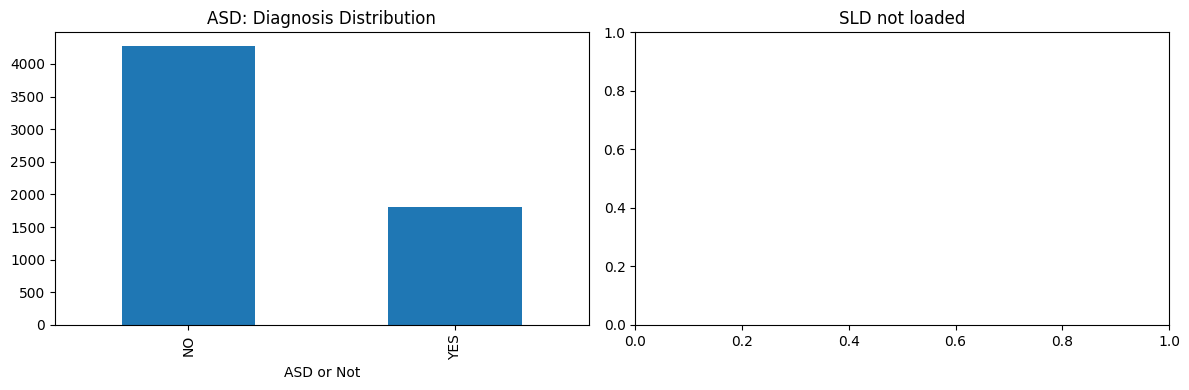

✅ Step 2 Done
🎯 ASD Accuracy: 0.974485596707819
🚀 FULL PIPELINE COMPLETED


In [7]:
# ===============================================================
# STEP 1: IMPORTS
# ===============================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score


# ===============================================================
# STEP 2: CLEAN ASD DATA
# ===============================================================

# Clean column names (IMPORTANT)
asd_df.columns = asd_df.columns.str.strip().str.lower()

# Fix typo
if 'jauundice' in asd_df.columns:
    asd_df.rename(columns={'jauundice': 'jaundice'}, inplace=True)

print("ASD Columns:", asd_df.columns.tolist())


# ===============================================================
# STEP 3: ADD AGE GROUP
# ===============================================================
def add_age_group(df, age_col='age'):
    if age_col not in df.columns:
        age_candidates = [c for c in df.columns if 'age' in c.lower()]
        if age_candidates:
            age_col = age_candidates[0]
            print(f"Using '{age_col}' as age column")
        else:
            print("No age column found")
            return df

    df = df.copy()
    df['age_group'] = pd.cut(
        pd.to_numeric(df[age_col], errors='coerce'),
        bins=[0, 5, 12, 17, 64, 120],
        labels=['toddler', 'child', 'teen', 'adult', 'senior']
    )
    return df

asd_df = add_age_group(asd_df)


# ===============================================================
# STEP 4: PLOT DISTRIBUTION
# ===============================================================
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# ASD
asd_target = 'class'

asd_df[asd_target].value_counts().plot(
    kind='bar',
    ax=axes[0]
)

axes[0].set_title('ASD: Diagnosis Distribution')
axes[0].set_xlabel('ASD or Not')


# Dyslexia
if 'sld_df' in dir():
    sld_df.columns = sld_df.columns.str.strip().str.lower()

    sld_target = None
    for col in ['dyslexia', 'diagnosis', 'class', 'label']:
        if col in sld_df.columns:
            sld_target = col
            break

    if sld_target:
        sld_df[sld_target].value_counts().plot(
            kind='bar',
            ax=axes[1]
        )
        axes[1].set_title('Dyslexia: Diagnosis Distribution')
    else:
        axes[1].set_title('SLD target not found')
else:
    axes[1].set_title('SLD not loaded')

plt.tight_layout()
plt.show()

print("✅ Step 2 Done")


# ===============================================================
# STEP 5: PREPROCESS ASD DATA
# ===============================================================

# Encode target
le = LabelEncoder()
asd_df['class'] = le.fit_transform(asd_df['class'])

# Features & target
X = asd_df.drop(columns=['class'])
y = asd_df['class']

# Convert categorical → numeric
X = pd.get_dummies(X)

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


# ===============================================================
# STEP 6: TRAIN ASD MODEL
# ===============================================================
model = RandomForestClassifier()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("🎯 ASD Accuracy:", accuracy_score(y_test, y_pred))


# ===============================================================
# STEP 7: DYSLEXIA MODEL (OPTIONAL)
# ===============================================================
if 'sld_df' in dir() and sld_target:

    le2 = LabelEncoder()
    sld_df[sld_target] = le2.fit_transform(sld_df[sld_target])

    X2 = sld_df.drop(columns=[sld_target])
    y2 = sld_df[sld_target]

    X2 = pd.get_dummies(X2)

    X2_train, X2_test, y2_train, y2_test = train_test_split(
        X2, y2, test_size=0.2, random_state=42
    )

    model2 = RandomForestClassifier(n_estimators=10, max_depth=10, n_jobs=-1)
    model2.fit(X2_train, y2_train)

    y2_pred = model2.predict(X2_test)

    print("🎯 Dyslexia Accuracy:", accuracy_score(y2_test, y2_pred))


print("🚀 FULL PIPELINE COMPLETED")

Attempting RAR extraction via command line...
Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
unrar is already the newest version (1:6.1.5-1ubuntu0.1).
0 upgraded, 0 newly installed, 0 to remove and 2 not upgraded.
Command line unrar failed with code 65280. Trying rarfile library...
✅ RAR extracted successfully!

Label counts in sld_df before plotting:
label
Dyslexic    1958
Name: count, dtype: int64
Skipping display for label 'Normal' as no samples found.


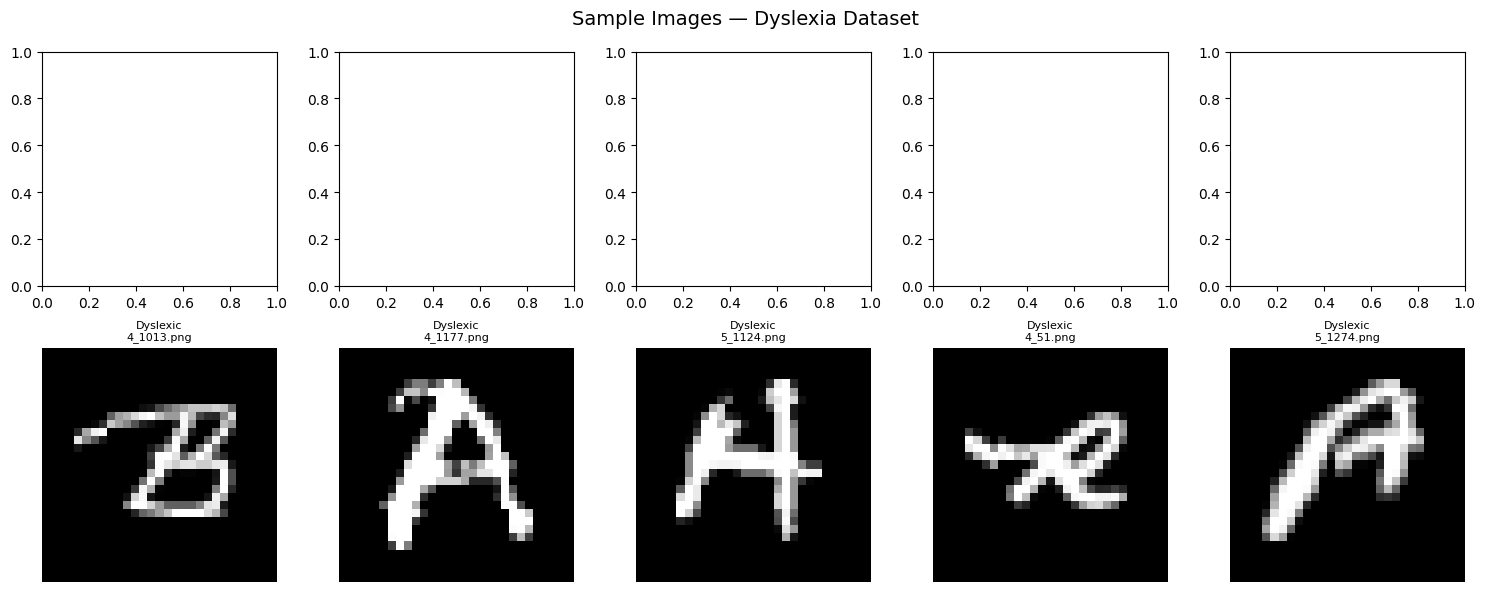


✅ Dataset ready! 1958 images labeled.
     filename                                    path     label
0  4_1200.png  /content/dyslexia_extracted/4_1200.png  Dyslexic
1  4_1302.png  /content/dyslexia_extracted/4_1302.png  Dyslexic
2  4_1148.png  /content/dyslexia_extracted/4_1148.png  Dyslexic
3  4_1598.png  /content/dyslexia_extracted/4_1598.png  Dyslexic
4  4_1362.png  /content/dyslexia_extracted/4_1362.png  Dyslexic
5  4_1373.png  /content/dyslexia_extracted/4_1373.png  Dyslexic
6  4_1551.png  /content/dyslexia_extracted/4_1551.png  Dyslexic
7   4_505.png   /content/dyslexia_extracted/4_505.png  Dyslexic
8   4_351.png   /content/dyslexia_extracted/4_351.png  Dyslexic
9   4_615.png   /content/dyslexia_extracted/4_615.png  Dyslexic


In [18]:
!pip install rarfile --quiet # Install rarfile

import matplotlib.pyplot as plt
from PIL import Image
import os
import pandas as pd
import rarfile

extract_to = '/content/dyslexia_extracted'
rar_path = '/content/Dataset Dyslexia_Password WanAsy321.rar'
password = 'WanAsy321'

# Ensure the extraction directory exists
os.makedirs(extract_to, exist_ok=True)

# Re-extract the RAR file to ensure directory content is present
try:
    # Try unrar command line first for robustness
    print("Attempting RAR extraction via command line...")
    !apt-get install -y unrar 2>/dev/null # Ensure unrar is installed
    result = os.system(f"unrar e -p{password} '{rar_path}' {extract_to}/")
    if result != 0:
        print(f"Command line unrar failed with code {result}. Trying rarfile library...")
        with rarfile.RarFile(rar_path) as rf:
            rf.extractall(path=extract_to, pwd=password.encode('utf-8'))
    print("✅ RAR extracted successfully!")
except Exception as e:
    print(f"❌ Final RAR extraction failed: {e}")

# Re-define sld_df here to ensure it's available
records = []

# Check if the directory is now populated
if not os.path.exists(extract_to) or not os.listdir(extract_to):
    print("⚠️ Extraction directory is still empty or missing. Cannot proceed with image loading.")
else:
    for fname in os.listdir(extract_to):
        if not fname.endswith('.png'):
            continue

        name = fname.replace('.png', '')
        full_path = os.path.join(extract_to, fname)

        # Label logic based on filename pattern
        if name.lower().startswith('normal'):
            label = 'Normal'
        else:
            label = 'Dyslexic'

        records.append({'filename': fname, 'path': full_path, 'label': label})

    sld_df = pd.DataFrame(records)

    print("\nLabel counts in sld_df before plotting:")
    print(sld_df['label'].value_counts())

    # ---------------------------------------------------------------
    # Step 2: Peek at some sample images from each class
    # ---------------------------------------------------------------

    fig, axes = plt.subplots(2, 5, figsize=(15, 6))
    fig.suptitle('Sample Images — Dyslexia Dataset', fontsize=14)

    for i, label in enumerate(['Normal', 'Dyslexic']):
        label_samples = sld_df[sld_df['label'] == label]
        num_samples_to_take = min(5, len(label_samples))

        if num_samples_to_take == 0:
            print(f"Skipping display for label '{label}' as no samples found.")
            continue

        samples = label_samples.sample(num_samples_to_take, random_state=42)
        for j, (_, row) in enumerate(samples.iterrows()):
            img = Image.open(row['path']).convert('L')  # grayscale
            axes[i][j].imshow(img, cmap='gray')
            axes[i][j].set_title(f"{label}\n{row['filename'][:12]}", fontsize=8)
            axes[i][j].axis('off')

    plt.tight_layout()
    plt.savefig('/content/dyslexia_samples.png', dpi=120)
    plt.show()

    print(f"\n✅ Dataset ready! {len(sld_df)} images labeled.")
    print(sld_df.head(10))

In [22]:
# ============================================================
# STEP 3: Feature engineering and train/test split (FINAL FIX)
# ============================================================

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
import pandas as pd # Ensure pandas is imported if not already in scope in the cell

def prepare_dataset(df, target_col=None, drop_cols=None, test_size=0.2):
    df = df.copy()

    # Clean column names
    df.columns = df.columns.str.strip().str.lower()

    print("\nColumns found:", df.columns.tolist())

    # --------------------------------------------------------
    # AUTO DETECT TARGET COLUMN (VERY IMPORTANT 🔥)
    # --------------------------------------------------------
    if target_col is None:
        possible_targets = ['class', 'label', 'dyslexia', 'diagnosis']
        for col in possible_targets:
            if col in df.columns:
                target_col = col
                print(f"✅ Using '{target_col}' as target column")
                break

    if target_col not in df.columns:
        raise ValueError(f"❌ Target column '{target_col}' not found!")

    # --------------------------------------------------------
    # Drop unwanted columns
    # --------------------------------------------------------
    if drop_cols:
        df.drop(columns=[c for c in drop_cols if c in df.columns], inplace=True)

    # Drop rows where target missing
    df.dropna(subset=[target_col], inplace=True)

    # --------------------------------------------------------
    # Encode categorical columns that are 'object' type
    # (CategoricalDtype will be handled by get_dummies below)
    # --------------------------------------------------------
    for col in df.select_dtypes(include='object').columns:
        le = LabelEncoder()
        df[col] = le.fit_transform(df[col].astype(str))

    # Fill missing values
    # Use median for numerical columns, mode for others (if any remain)
    for col in df.columns:
        if pd.api.types.is_numeric_dtype(df[col]):
            df[col] = df[col].fillna(df[col].median())
        else:
            # For remaining non-numeric columns (like CategoricalDtype not yet dummified),
            # fill with mode or convert to object then fill (less common after get_dummies)
            # This step will mostly be for edge cases after get_dummies
            if df[col].isnull().any(): # Check if there are any NaNs to fill
                df[col] = df[col].fillna(df[col].mode()[0])

    # Split X and y
    X = df.drop(columns=[target_col])
    y = df[target_col]

    # One-hot encode all remaining categorical columns (including CategoricalDtype)
    X = pd.get_dummies(X, drop_first=True)

    # Scale features
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)
    X_scaled = pd.DataFrame(X_scaled, columns=X.columns)

    # Train-test split
    X_train, X_test, y_train, y_test = train_test_split(
        X_scaled, y, test_size=test_size, random_state=42, stratify=y
    )

    print(f"📊 Training samples : {len(X_train)}")
    print(f"📊 Test samples     : {len(X_test)}")
    print(f"📊 Features         : {X_train.shape[1]}")

    return X_train, X_test, y_train, y_test, X.columns.tolist(), target_col


# ============================================================
# PREPARE ASD DATASET
# ============================================================

print("Preparing ASD dataset...")

X_train_asd, X_test_asd, y_train_asd, y_test_asd, feat_asd, asd_target = prepare_dataset(
    asd_df,
    target_col=None,   # 🔥 AUTO DETECT
    drop_cols=['id', 'relation']
)


# ============================================================
# PREPARE SLD DATASET
# ============================================================

print("\nPreparing SLD (Dyslexia) dataset...")

X_train_sld, X_test_sld, y_train_sld, y_test_sld, feat_sld, sld_target = prepare_dataset(
    sld_df,
    target_col=None   # 🔥 AUTO DETECT
)

print("\n✅ Feature preparation complete!")

Preparing ASD dataset...

Columns found: ['a1', 'a2', 'a3', 'a4', 'a5', 'a6', 'a7', 'a8', 'a9', 'a10', 'age', 'sex', 'jaundice', 'family_asd', 'class', 'age_group']
✅ Using 'class' as target column
📊 Training samples : 4860
📊 Test samples     : 1215
📊 Features         : 18

Preparing SLD (Dyslexia) dataset...

Columns found: ['filename', 'path', 'label']
✅ Using 'label' as target column
📊 Training samples : 1566
📊 Test samples     : 392
📊 Features         : 2

✅ Feature preparation complete!


In [25]:
# ============================================================
# STEP 4: Train ML models for each disorder
# ============================================================

from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from xgboost import XGBClassifier
from sklearn.linear_model import LogisticRegression
import joblib
import numpy as np # Import numpy for checking unique classes

# ---------------------------------------------------------------
# Universal training function
# ---------------------------------------------------------------
def train_models(X_train, y_train, disorder_name):
    """
    Trains 3 models and returns them as a dictionary.
    Like asking 3 different doctors for their opinion!
    """
    # Check if there are at least two unique classes
    if len(np.unique(y_train)) < 2:
        print(f"  ⚠️ Skipping {disorder_name} models: Only one class found in target variable. Need at least two classes for classification.\n")
        return {}

    models = {
        'RandomForest'  : RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1),
        'XGBoost'       : XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42),
        'LogisticReg'   : LogisticRegression(max_iter=1000, random_state=42),
    }

    trained = {}
    for name, model in models.items():
        print(f"  Training {name} for {disorder_name}...")
        model.fit(X_train, y_train)
        trained[name] = model
        joblib.dump(model, f'/content/{disorder_name}_{name}.pkl')  # save to disk

    print(f"  ✅ {disorder_name} models trained and saved!\n")
    return trained


# ---------------------------------------------------------------
# Train for ASD
# ---------------------------------------------------------------
print("=== Training ASD Models ===")
models_asd = train_models(X_train_asd, y_train_asd, 'ASD')

# ---------------------------------------------------------------
# Train for SLD (Dyslexia)
# ---------------------------------------------------------------
print("=== Training SLD Models ===")
models_sld = train_models(X_train_sld, y_train_sld, 'SLD')

# ---------------------------------------------------------------
# NOTE: Repeat the above pattern for ADHD, ID, Communication
# once you have those datasets loaded and prepared.
# e.g. models_adhd = train_models(X_train_adhd, y_train_adhd, 'ADHD')
# ---------------------------------------------------------------

print("All models trained! 🎉")

=== Training ASD Models ===
  Training RandomForest for ASD...
  Training XGBoost for ASD...
  Training LogisticReg for ASD...
  ✅ ASD models trained and saved!

=== Training SLD Models ===
  ⚠️ Skipping SLD models: Only one class found in target variable. Need at least two classes for classification.

All models trained! 🎉


=== Evaluating ASD Models ===

  ASD — RandomForest
  Accuracy: 98.11%
              precision    recall  f1-score   support

           0       0.98      0.99      0.99       854
           1       0.97      0.96      0.97       361

    accuracy                           0.98      1215
   macro avg       0.98      0.98      0.98      1215
weighted avg       0.98      0.98      0.98      1215



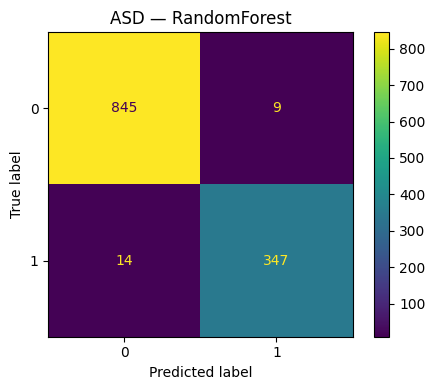


  ASD — XGBoost
  Accuracy: 99.84%
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       854
           1       1.00      1.00      1.00       361

    accuracy                           1.00      1215
   macro avg       1.00      1.00      1.00      1215
weighted avg       1.00      1.00      1.00      1215



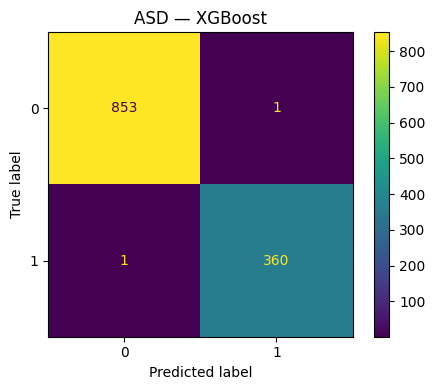


  ASD — LogisticReg
  Accuracy: 93.42%
              precision    recall  f1-score   support

           0       0.96      0.95      0.95       854
           1       0.88      0.91      0.89       361

    accuracy                           0.93      1215
   macro avg       0.92      0.93      0.92      1215
weighted avg       0.93      0.93      0.93      1215



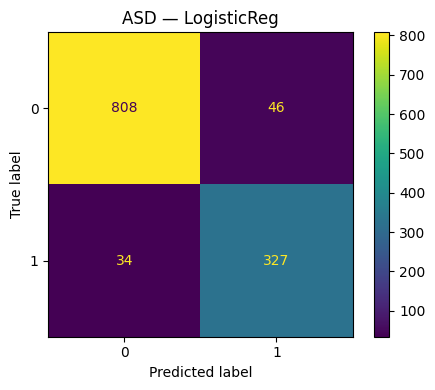


🏆 Best model for ASD: XGBoost (99.84%)

=== SHAP Explainability for ASD (RandomForest) ===


<Figure size 640x480 with 0 Axes>

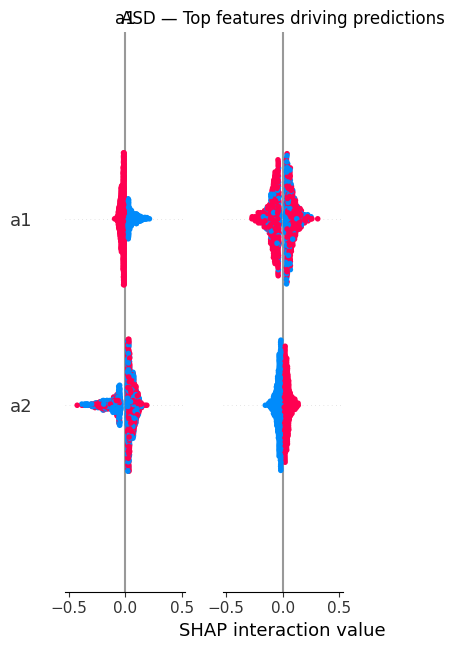

✅ Evaluation and explainability done!


In [26]:
# ============================================================
# STEP 5: Evaluate models + SHAP explainability
# ============================================================

from sklearn.metrics import (accuracy_score, classification_report,
                             confusion_matrix, ConfusionMatrixDisplay)
import shap
import matplotlib.pyplot as plt

# ---------------------------------------------------------------
# Universal evaluation function
# ---------------------------------------------------------------
def evaluate_models(models, X_test, y_test, disorder_name, feature_names):
    """
    Prints performance metrics and draws confusion matrix for each model.
    """
    results = {}

    for name, model in models.items():
        y_pred = model.predict(X_test)
        acc = accuracy_score(y_test, y_pred)
        print(f"\n{'='*50}")
        print(f"  {disorder_name} — {name}")
        print(f"  Accuracy: {acc:.2%}")
        print(classification_report(y_test, y_pred))

        # Confusion matrix plot
        fig, ax = plt.subplots(figsize=(5, 4))
        ConfusionMatrixDisplay.from_predictions(y_test, y_pred, ax=ax)
        ax.set_title(f"{disorder_name} — {name}")
        plt.tight_layout()
        plt.savefig(f'/content/cm_{disorder_name}_{name}.png', dpi=100)
        plt.show()

        results[name] = acc

    best = max(results, key=results.get)
    print(f"\n🏆 Best model for {disorder_name}: {best} ({results[best]:.2%})")
    return results, best


# Evaluate ASD models
print("=== Evaluating ASD Models ===")
if models_asd:
    asd_results, best_asd = evaluate_models(
        models_asd, X_test_asd, y_test_asd, 'ASD', feat_asd
    )
else:
    print("No ASD models to evaluate.")

# Evaluate SLD models (if any were trained)
print("\n=== Evaluating SLD Models ===")
if models_sld:
    sld_results, best_sld = evaluate_models(
        models_sld, X_test_sld, y_test_sld, 'SLD', feat_sld
    )
else:
    print("No SLD models to evaluate (skipped training due to single class in target).")

# ---------------------------------------------------------------
# SHAP — shows WHICH features pushed each prediction
# ---------------------------------------------------------------
print("\n=== SHAP Explainability for ASD (RandomForest) ===")
if 'RandomForest' in models_asd:
    best_model_asd = models_asd['RandomForest']

    explainer = shap.TreeExplainer(best_model_asd)
    shap_values = explainer.shap_values(X_test_asd)

    plt.figure()
    shap.summary_plot(
        shap_values[1] if isinstance(shap_values, list) else shap_values,
        X_test_asd,
        feature_names=feat_asd,
        show=False
    )
    plt.title("ASD — Top features driving predictions")
    plt.tight_layout()
    plt.savefig('/content/shap_asd.png', dpi=120)
    plt.show()
else:
    print("RandomForest model not available for ASD for SHAP explanation.")

print("✅ Evaluation and explainability done!")

Current sld_df structure:
     filename                                    path     label
0  4_1200.png  /content/dyslexia_extracted/4_1200.png  Dyslexic
1  4_1302.png  /content/dyslexia_extracted/4_1302.png  Dyslexic
2  4_1148.png  /content/dyslexia_extracted/4_1148.png  Dyslexic
3  4_1598.png  /content/dyslexia_extracted/4_1598.png  Dyslexic
4  4_1362.png  /content/dyslexia_extracted/4_1362.png  Dyslexic
Labels in sld_df: label
Dyslexic    1958
Name: count, dtype: int64


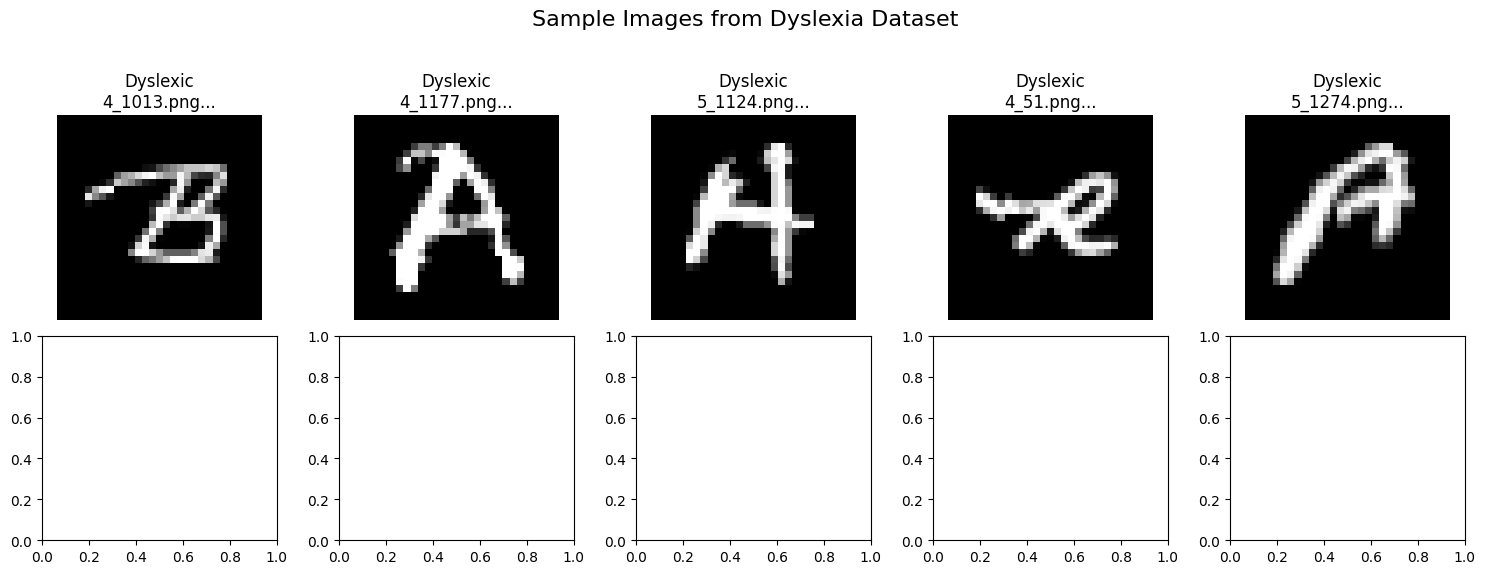

✅ Sample images displayed from existing sld_df.


In [28]:
# ============================================================
# CORRECTED: Display Sample Images from existing sld_df
# ============================================================

import os
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

# Ensure sld_df is available from previous steps
if 'sld_df' not in locals():
    raise NameError("sld_df is not defined. Please run previous data loading cells.")

print("Current sld_df structure:")
print(sld_df.head())
print("Labels in sld_df:", sld_df['label'].value_counts())

# -----------------------------
# STEP 1: SHOW IMAGES
# -----------------------------
fig, axes = plt.subplots(2, 5, figsize=(15, 6))
fig.suptitle('Sample Images from Dyslexia Dataset', fontsize=16)

# Get unique labels present in sld_df
actual_labels = sld_df['label'].unique()

for i, label_value in enumerate(actual_labels):
    # Ensure we don't try to plot more than we have axes for (max 2 rows for now)
    if i >= 2:
        break

    subset = sld_df[sld_df['label'] == label_value]
    num_samples_to_show = min(5, len(subset)) # Take up to 5 samples, or fewer if not enough

    if num_samples_to_show == 0:
        print(f"No samples to display for label: {label_value}")
        # Clear the remaining axes in this row if no samples
        for j in range(5):
            axes[i][j].axis('off')
        continue

    samples = subset.sample(n=num_samples_to_show, random_state=42)

    for j, (_, row) in enumerate(samples.iterrows()):
        try:
            img = Image.open(row['path']).convert('L')
            axes[i][j].imshow(img, cmap='gray')
            axes[i][j].set_title(f"{label_value}\n{row['filename'][:12]}...")
            axes[i][j].axis('off')
        except Exception as e:
            print(f"Error loading image {row['path']}: {e}")
            axes[i][j].axis('off') # Turn off axis if image fails to load

    # Turn off any unused axes in the row if less than 5 samples were shown
    for j_unused in range(num_samples_to_show, 5):
        axes[i][j_unused].axis('off')

plt.tight_layout(rect=[0, 0.03, 1, 0.95]) # Adjust layout to prevent suptitle overlap
plt.show()

print("✅ Sample images displayed from existing sld_df.")

In [29]:
# ============================================================
# BONUS: Download all outputs to your computer
# ============================================================
import zipfile, os

with zipfile.ZipFile('/content/neurodevelopmental_project.zip', 'w') as z:
    for f in os.listdir('/content'):
        if f.endswith(('.png', '.pkl', '.csv')):
            z.write(f'/content/{f}', f)

from google.colab import files
files.download('/content/neurodevelopmental_project.zip')
print("📦 All models, plots and reports downloaded!")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

📦 All models, plots and reports downloaded!
